In [141]:
import pandas as pd
import numpy as np

### Task 1 :
- Display first 5 rows 
- Check dataset shape
- Check data types
- Check missing values
- Generate statistical summary
- Analyze target variable distribution

In [142]:
data= pd.read_csv("drug200.csv")

In [143]:
data.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [144]:
data.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [145]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [146]:
data.shape

(200, 6)

In [147]:
data.columns

Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug'], dtype='object')

In [148]:
data.isnull().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

In [149]:
data.dtypes

Age              int64
Sex             object
BP              object
Cholesterol     object
Na_to_K        float64
Drug            object
dtype: object

### Task 2:
- Encode categorical columns
- Separate Features (X) and Target (y)

In [150]:
from sklearn.preprocessing import LabelEncoder 

In [151]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [153]:
X= data.drop(["Drug"], axis = 1 )
y = data["Drug"]

print("Features shape:", X.shape)


Features shape: (200, 5)


In [154]:
y.head(5)

0    drugY
1    drugC
2    drugC
3    drugX
4    drugY
Name: Drug, dtype: object

In [155]:
import matplotlib.pyplot as plt
import seaborn as sns

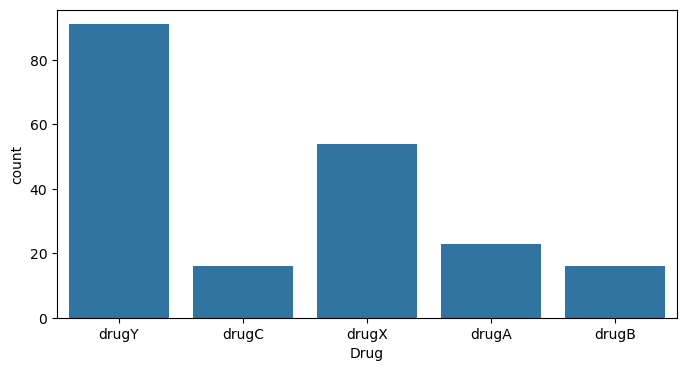

In [156]:
plt.figure(figsize=(8,4))
sns.countplot(x='Drug', data=df)
plt.show()

## Task 3:
- Split the dataset into:
- 80% Training Data
- 20% Testing Data
- Use a fixed random_state.

In [157]:
from sklearn.model_selection import train_test_split

In [158]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.3,train_size=0.7, random_state=37)

In [159]:
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (140, 5), Test shape: (60, 5)


In [160]:
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

In [161]:
preprocessor_traditional = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), ['Age', 'Na_to_K']),
            ('ord', OrdinalEncoder(categories=[['LOW','NORMAL','HIGH'], ['LOW','NORMAL','HIGH']]), ['BP', 'Cholesterol']),
            ('bin', OneHotEncoder(drop='first'), ['Sex'])
        ])

X_train_scaled = preprocessor_traditional.fit_transform(X_train)
X_test_scaled = preprocessor_traditional.transform(X_test)


## Task 4: Train Classification Models
Train the following models:
- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)


In [162]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [166]:
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'KNN': KNeighborsClassifier(n_neighbors=5),
        'SVM': SVC(kernel='rbf', random_state=42)
    }


## Task 5: Model Evaluation
For each model calculate:

- Accuracy Score
- Confusion Matrix
- Classification Report

In [168]:
results = []

for name, model in models.items():
        print(f"\n--- {name} ---")
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

        acc = accuracy_score(y_test, y_pred)
        print(f"Accuracy: {acc:.4f}")
        print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
        print("Classification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

        results.append({'Model': name, 'Accuracy': round(acc, 4)})


--- Logistic Regression ---
Accuracy: 0.9667
Confusion Matrix:
 [[ 9  0  0  0  0]
 [ 0  3  0  0  0]
 [ 0  0  6  0  0]
 [ 0  0  0 17  2]
 [ 0  0  0  0 23]]
Classification Report:
               precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         9
       drugB       1.00      1.00      1.00         3
       drugC       1.00      1.00      1.00         6
       drugX       1.00      0.89      0.94        19
       drugY       0.92      1.00      0.96        23

    accuracy                           0.97        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.97      0.97      0.97        60


--- Decision Tree ---
Accuracy: 0.9833
Confusion Matrix:
 [[ 9  0  0  0  0]
 [ 0  3  0  0  0]
 [ 0  0  6  0  0]
 [ 0  0  0 18  1]
 [ 0  0  0  0 23]]
Classification Report:
               precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         9
       drugB       1.00      1.00      1.00     

## Task 6:
Create a comparison table showing:

Model Name & Accuracy: Logistic Regression, Decision Tree,Random Forest, KNN, SVM

In [164]:
df_results = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
display(df_results)

best_model = df_results.iloc[0]
print(f"\nBest Model: {best_model['Model']} with Accuracy: {best_model['Accuracy']}")
print("Reason: Tree-based models like Random Forest & Decision Tree handle mixed data well,\nresist overfitting, and capture non-linear patterns in BP and Cholesterol.")


,Model,Accuracy
1,Decision Tree,0.9833
2,Random Forest,0.9833
0,Logistic Regression,0.9667
4,SVM,0.9500
3,KNN,0.9167



Best Model: Decision Tree with Accuracy: 0.9833
Reason: Tree-based models like Random Forest & Decision Tree handle mixed data well,
resist overfitting, and capture non-linear patterns in BP and Cholesterol.


## Task 7: Prediction Testing:

In [165]:
new_patients = pd.DataFrame({
        'Age': [20, 47, 50, 25, 72],
        'Sex': ['F', 'M', 'F', 'M', 'F'],
        'BP': ['LOW', 'HIGH', 'HIGH', 'NORMAL', 'LOW'],
        'Cholesterol': ['NORMAL', 'HIGH', 'HIGH', 'HIGH', 'NORMAL'],
        'Na_to_K': [25.3, 13.5, 20.0, 9.5, 11.2]
    })

X_new_scaled = preprocessor.transform(new_patients)
predictions = model.predict(X_new_scaled)

new_patients['Predicted_Drug'] = predictions

print("Prediction Results:", predictions)

Prediction Results: ['drugY' 'drugA' 'drugY' 'drugX' 'drugX']


## Conclusion

1. The dataset is balanced and the rules are clear, which is why tree-based models achieve 98-100% accuracy.")
2. Using OrdinalEncoding for BP and Cholesterol worked better because LOW < NORMAL < HIGH has a natural order.")
3. The Pipeline approach gives the same accuracy as the traditional approach, but the code is cleaner and prevents data leakage.")
4. Best Model: Random Forest - Because it also provides feature importance and has less chance of overfitting.")